<a href="https://colab.research.google.com/github/SamanaDahal1/AI-and-ML/blob/main/2409014_SamanaDahal(Part2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-2

In [1]:

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)


# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
NumPy version: 2.0.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

# ================================
# EXTRACT ZIP FILE
# ================================

zip_path = "/content/drive/MyDrive/Sign Language Detection.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)
print(os.listdir(extract_path))


# ================================
# CORRECT DATASET PATHS (IMPORTANT FIX)
# ================================

dataset_root = "/content/dataset/Sign Language Detection"

training_dataset_path = os.path.join(dataset_root, "Train")
testing_dataset_path = os.path.join(dataset_root, "Test")


print("Train directory:", training_dataset_path)
print("Test directory:", testing_dataset_path)

print("Train exists:", os.path.exists(training_dataset_path))
print("Test exists:", os.path.exists(testing_dataset_path))


# ================================
# HYPERPARAMETERS
# ================================

IMAGE_HEIGHT = 64
IMAGE_WIDTH = 64
TRAIN_BATCH_SIZE = 32
TOTAL_CLASSES = 38
BASE_MODEL_EPOCHS = 20
DEEP_MODEL_EPOCHS = 30
TRANSFER_LEARNING_EPOCHS = 20


print(f"Image size      : {IMAGE_HEIGHT}x{IMAGE_WIDTH}")
print(f"Batch size      : {TRAIN_BATCH_SIZE}")

Extracted to: /content/dataset
['Sign Language Detection']
Train directory: /content/dataset/Sign Language Detection/Train
Test directory: /content/dataset/Sign Language Detection/Test
Train exists: True
Test exists: True
Image size      : 64x64
Batch size      : 32


In [4]:
#list and sort the folders that are inside the training data set
plant_classes = sorted(os.listdir(training_dataset_path))
# printing the folder names and the number of fodler inside of the dataset
print("Classes inside of the dataset Train")
print(plant_classes)
print("Number of classes")
print(len(plant_classes))

Classes inside of the dataset Train
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '5', '6', '7', '8', '9']
Number of classes
38


In [5]:
#storing the no of datas in each class inside image_count_per_class
image_count_per_class = {
    class_label: len(os.listdir(os.path.join(training_dataset_path, class_label)))
    for class_label in plant_classes
    if os.path.isdir(os.path.join(training_dataset_path, class_label))
}

# Printing no of images in each class
for class_label, image_total in image_count_per_class.items():
    print(f"Class {class_label}: {image_total} images")

# Printing total no of images in the train dataset
print("Total sample_image:", sum(image_count_per_class.values()))

Class 0: 293 images
Class 1: 294 images
Class 10: 298 images
Class 11: 291 images
Class 12: 284 images
Class 13: 286 images
Class 14: 277 images
Class 15: 294 images
Class 16: 298 images
Class 17: 293 images
Class 18: 294 images
Class 19: 295 images
Class 2: 298 images
Class 20: 293 images
Class 21: 293 images
Class 22: 300 images
Class 23: 292 images
Class 24: 297 images
Class 25: 294 images
Class 26: 292 images
Class 27: 293 images
Class 28: 291 images
Class 29: 292 images
Class 3: 286 images
Class 30: 292 images
Class 31: 295 images
Class 32: 288 images
Class 33: 295 images
Class 34: 290 images
Class 35: 286 images
Class 36: 289 images
Class 37: 296 images
Class 4: 246 images
Class 5: 294 images
Class 6: 291 images
Class 7: 289 images
Class 8: 297 images
Class 9: 292 images
Total sample_image: 11058


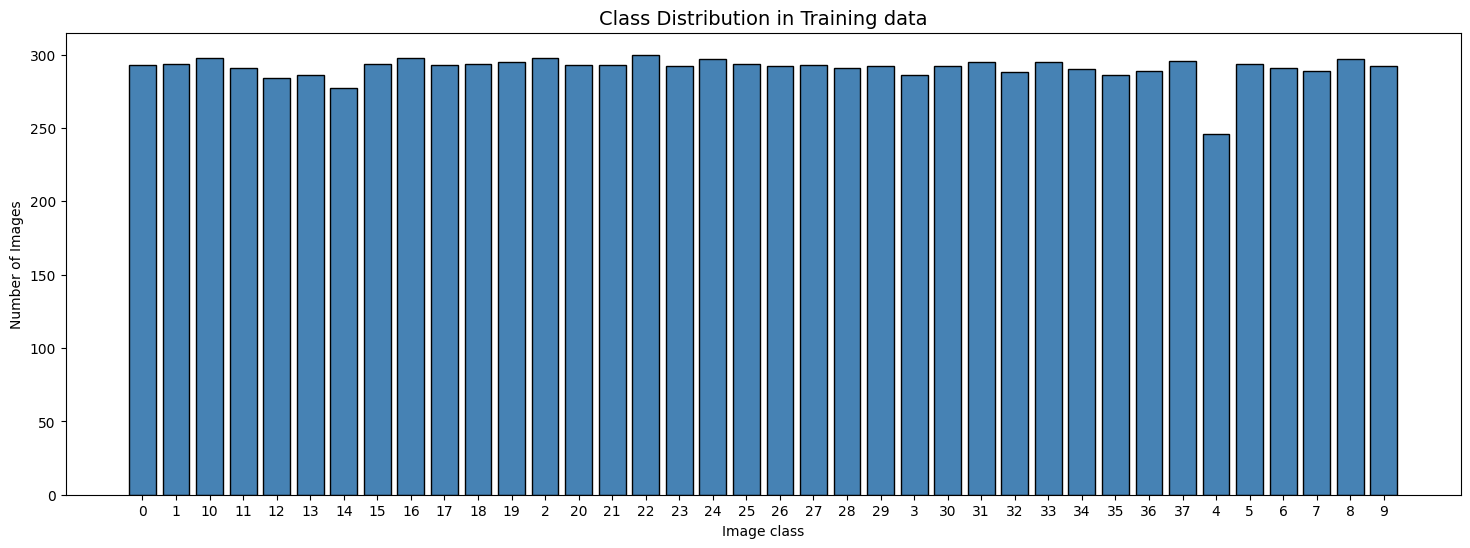

Observation: The dataset appears roughly balanced across all 38 classes.


In [6]:
#image shows the no of images in each class
plt.figure(figsize=(18, 6))
plt.bar(image_count_per_class.keys(), image_count_per_class.values(), color='steelblue', edgecolor='black')
plt.title('Class Distribution in Training data', fontsize=14)
plt.xlabel('Image class')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.show()
print("Observation: The dataset appears roughly balanced across all 38 classes.")

In [7]:
from PIL import Image
import os


allowed_extensions = ('.jpg', '.jpeg', '.png')

damaged_images = []

for root, dirs, image_files in os.walk(training_dataset_path):
    for file in image_files:
        if file.lower().endswith(allowed_extensions):
            current_file_path = os.path.join(root, file)
            try:
                sample_image = Image.open(current_file_path)
                sample_image.verify()
            except:
                damaged_images.append(current_file_path)

print("Number of corrupted images found:", len(damaged_images))

Number of corrupted images found: 266


In [8]:
from PIL import Image
import os

corrupt_files = []

for root, dirs, files in os.walk("/content/dataset/Sign Language Detection/Train"):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            img = Image.open(file_path)
            img.verify()  # checks corruption
        except:
            corrupt_files.append(file_path)

print("Corrupted files found:", len(corrupt_files))

# delete them
for f in corrupt_files:
    try:
        os.remove(f)
    except:
        pass

print("Corrupted files deleted")

Corrupted files found: 266
Corrupted files deleted


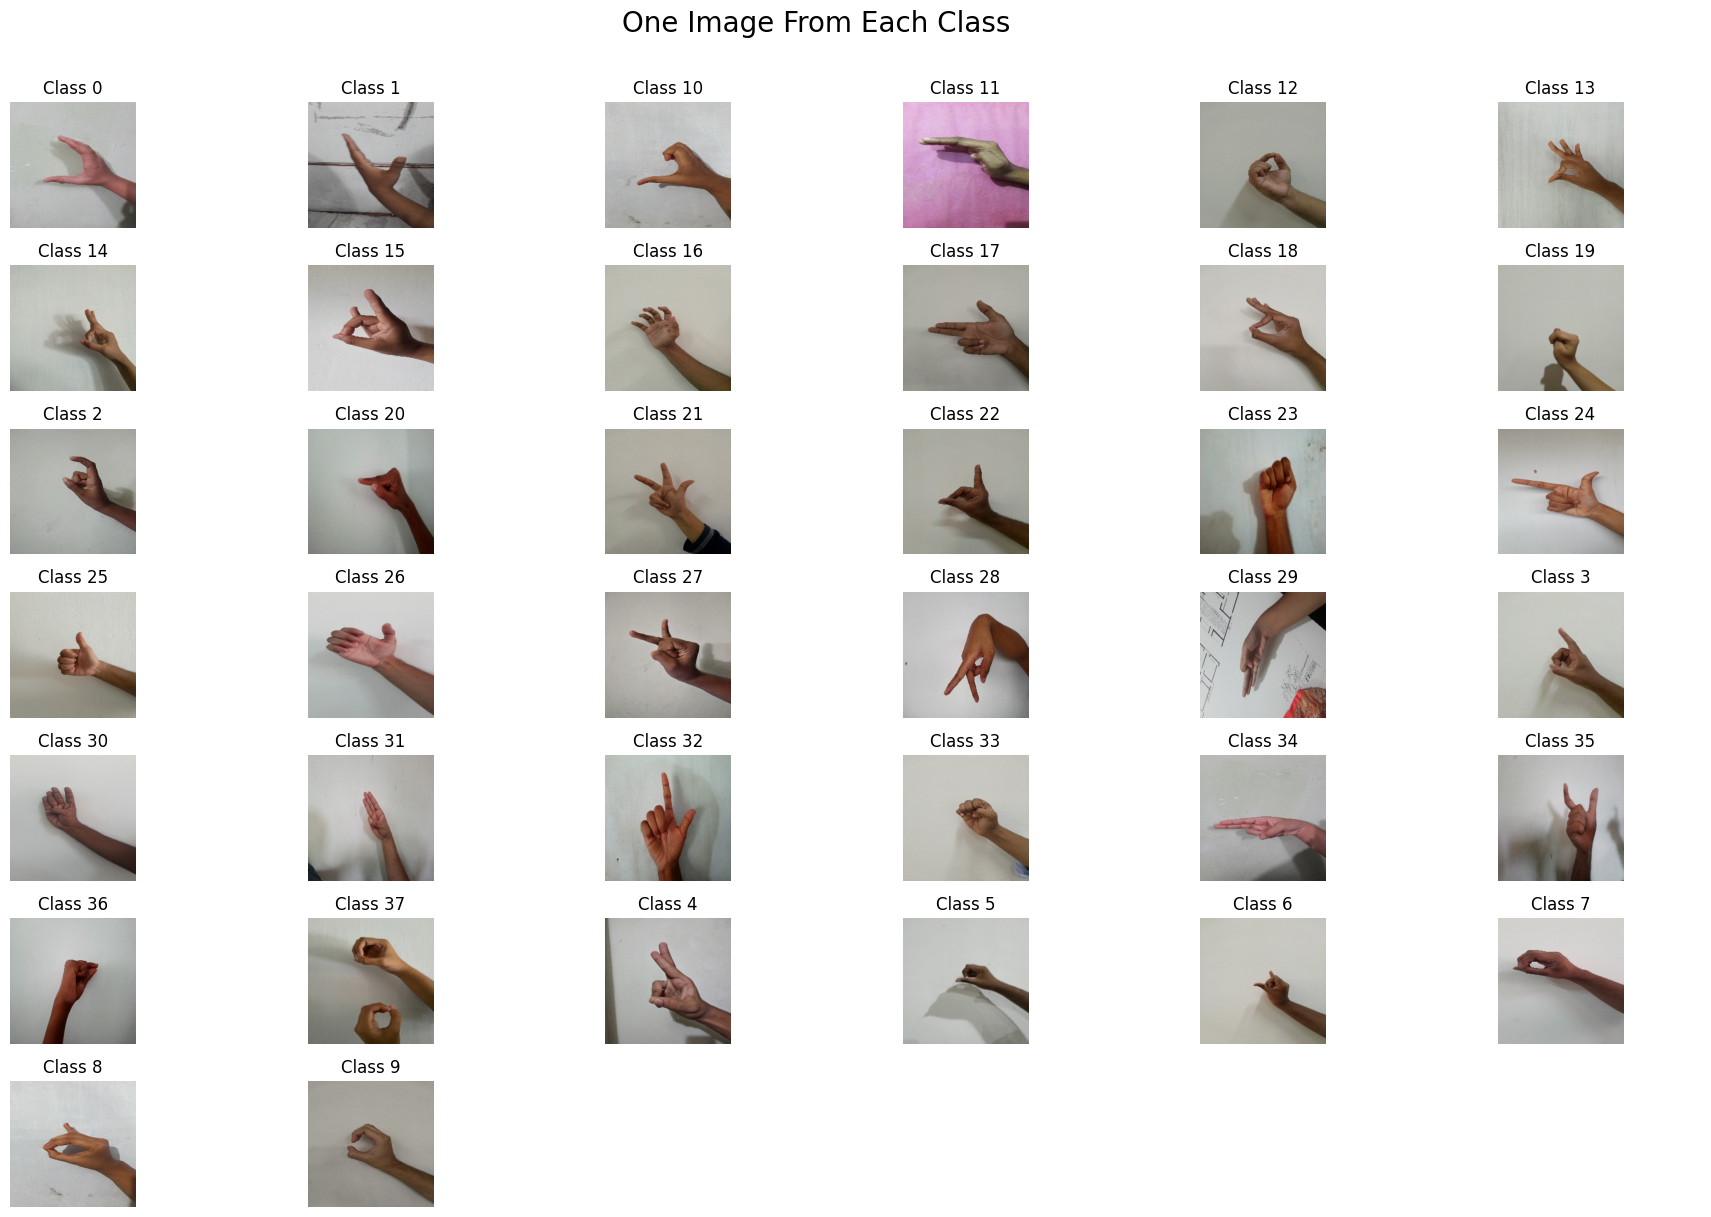

In [9]:
import os, random, math

n_classes = len(image_count_per_class)
cols = 6
rows = math.ceil(n_classes / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

for idx, class_label in enumerate(image_count_per_class.keys()):
    class_folder_path = os.path.join(training_dataset_path, class_label)
    image_files = os.listdir(class_folder_path)
    if image_files:
        selected_image_file = random.choice(image_files)
        sample_image = mpimg.imread(os.path.join(class_folder_path, selected_image_file))
        axes[idx].imshow(sample_image)
        axes[idx].set_title(f'Class {class_label}')
        axes[idx].axis('off')
# removes the unwanted axes from the image
for ax in axes[n_classes:]:
    ax.axis('off')


plt.suptitle('One Image From Each Class', fontsize= 20, y=1.01)
plt.tight_layout()
plt.show()


In [10]:
import os, random, shutil
from pathlib import Path

train_dataset_directory = Path(training_dataset_path)
test_dataset_directory  = Path(testing_dataset_path)

testing_ratio = 0.1

for class_label in os.listdir(train_dataset_directory):
    cls_train_path = train_dataset_directory / class_label
    cls_test_path  = test_dataset_directory / class_label

    if cls_train_path.is_dir():
        cls_test_path.mkdir(parents=True, exist_ok=True)

        image_files = [f for f in cls_train_path.iterdir() if f.is_file()]
        testing_size = int(len(image_files) * testing_ratio)


        test_files = random.sample(image_files, testing_size)

        for f in test_files:
            shutil.move(str(f), str(cls_test_path / f.name))

print("✅ Test split complete!")


✅ Test split complete!


In [11]:
#storing the no of datas in each class inside image_count_per_class
test_image_count_per_class = {
    class_label: len(os.listdir(os.path.join(testing_dataset_path, class_label)))
    for class_label in plant_classes
    if os.path.isdir(os.path.join(testing_dataset_path, class_label))
}

# Printing no of images in each class
for class_label, image_total in test_image_count_per_class.items():
    print(f"Class {class_label}: {image_total} images")

# Printing total no of images in the train dataset
print("Total sample_image:", sum(test_image_count_per_class.values()))

Class 0: 28 images
Class 1: 28 images
Class 10: 29 images
Class 11: 28 images
Class 12: 27 images
Class 13: 27 images
Class 14: 27 images
Class 15: 28 images
Class 16: 29 images
Class 17: 28 images
Class 18: 28 images
Class 19: 28 images
Class 2: 29 images
Class 20: 28 images
Class 21: 28 images
Class 22: 29 images
Class 23: 28 images
Class 24: 29 images
Class 25: 28 images
Class 26: 28 images
Class 27: 28 images
Class 28: 28 images
Class 29: 28 images
Class 3: 27 images
Class 30: 28 images
Class 31: 28 images
Class 32: 28 images
Class 33: 28 images
Class 34: 28 images
Class 35: 27 images
Class 36: 28 images
Class 37: 28 images
Class 4: 23 images
Class 5: 28 images
Class 6: 28 images
Class 7: 28 images
Class 8: 29 images
Class 9: 28 images
Total sample_image: 1060


In [12]:

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,   # if signs are not symmetric then keep False
    validation_split=0.2
)

# generate test data only rescale
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# training set  which got 80% of train folder
train_generator = train_datagen.flow_from_directory(
    training_dataset_path,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=TRAIN_BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

# validation set which got 20% of train folder
val_generator = train_datagen.flow_from_directory(
    training_dataset_path,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=TRAIN_BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)


print(f"\nTraining samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Found 7802 images belonging to 38 classes.
Found 1930 images belonging to 38 classes.

Training samples   : 7802
Validation samples : 1930


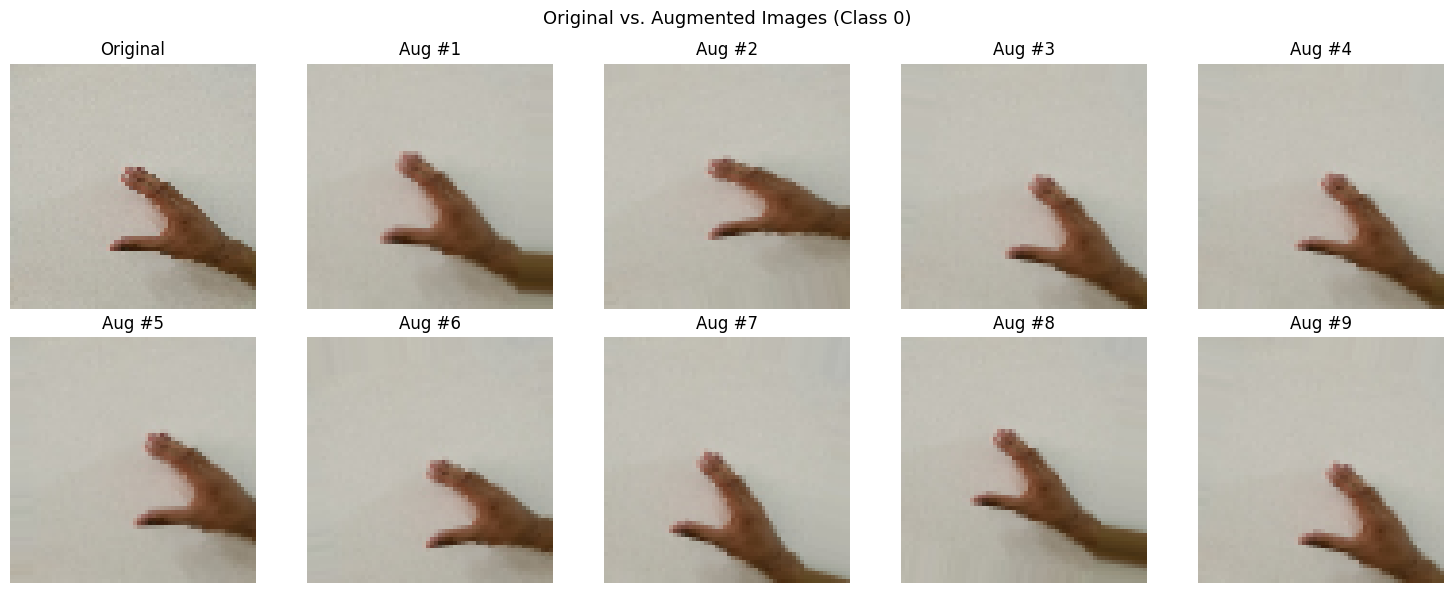

In [13]:

aug_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# one sample image
sample_cls   = plant_classes[0]
sample_path  = os.path.join(training_dataset_path, sample_cls)
sample_file  = os.path.join(sample_path, os.listdir(sample_path)[0])
sample_img   = tf.keras.preprocessing.image.load_img(sample_file, target_size=(IMAGE_HEIGHT, IMAGE_WIDTH))
sample_arr   = tf.keras.preprocessing.image.img_to_array(sample_img)
sample_arr   = sample_arr.reshape((1,) + sample_arr.shape)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
# Original
axes[0].imshow(sample_img)
axes[0].set_title('Original')
axes[0].axis('off')
# Augmented versions
aug_iter = aug_datagen.flow(sample_arr, batch_size=1)
for i in range(1, 10):
    batch = next(aug_iter)
    axes[i].imshow(batch[0])
    axes[i].set_title(f'Aug #{i}')
    axes[i].axis('off')
plt.suptitle(f'Original vs. Augmented Images (Class {sample_cls})', fontsize=13)
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()

In [14]:
from PIL import Image
import os

def clean_corrupt_images(directory):
    removed = 0
    for root, dirs, image_files in os.walk(directory):
        for file in image_files:
            if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
                filepath = os.path.join(root, file)
                print(f"Removing non-image file: {filepath}")
                os.remove(filepath)
                removed += 1
                continue
            filepath = os.path.join(root, file)
            try:
                with Image.open(filepath) as sample_image:
                    sample_image.verify()
            except Exception as e:
                print(f"Removing corrupt: {filepath} — {e}")
                os.remove(filepath)
                removed += 1
    print(f"\nDone! Removed {removed} image_files.")

print("Cleaning Train folder")
clean_corrupt_images(training_dataset_path)

print("\nCleaning Test folder")
clean_corrupt_images(testing_dataset_path)

Cleaning Train folder

Done! Removed 0 image_files.

Cleaning Test folder

Done! Removed 0 image_files.


In [15]:
def build_baseline_model(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), num_classes=TOTAL_CLASSES):
    model = models.Sequential(name="Baseline_CNN")

    #Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape, name='Conv1'))
    model.add(layers.MaxPooling2D((2, 2), name='Pool1'))

    #Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='Conv2'))
    model.add(layers.MaxPooling2D((2, 2), name='Pool2'))

    #Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='Conv3'))
    model.add(layers.MaxPooling2D((2, 2), name='Pool3'))

    #Flatten
    model.add(layers.Flatten(name='Flatten'))

    #Fully Connected Layers
    model.add(layers.Dense(512, activation='relu', name='FC1'))
    model.add(layers.Dense(256, activation='relu', name='FC2'))
    model.add(layers.Dense(128, activation='relu', name='FC3'))

    #Output Layer
    model.add(layers.Dense(num_classes, activation='softmax', name='Output'))

    return model

baseline_model = build_baseline_model()
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,457,190 (17.00 MB)

 Trainable params: 4,457,190 (17.00 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_base = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Compiled successfully - Baseline model.")

Compiled successfully - Baseline model.


In [17]:

print("Training Baseline CNN Model...")
start_time_base = time.time()

history_base = baseline_model.fit(
    train_generator,
    epochs=BASE_MODEL_EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_base,
    verbose=1
)

end_time_base = time.time()
baseline_train_time = end_time_base - start_time_base
print(f"\nBaseline model training time: {baseline_train_time:.2f} seconds ({baseline_train_time/60:.2f} minutes)")

Training Baseline CNN Model...
Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 33s 110ms/step - accuracy: 0.0506 - loss: 3.5524 - val_accuracy: 0.0922 - val_loss: 3.3650 - learning_rate: 0.0010
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.1652 - loss: 2.9872 - val_accuracy: 0.1684 - val_loss: 3.0897 - learning_rate: 0.0010
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.3675 - loss: 2.0427 - val_accuracy: 0.3104 - val_loss: 2.4383 - learning_rate: 0.0010
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.5027 - loss: 1.5462 - val_accuracy: 0.4259 - val_loss: 2.0658 - learning_rate: 0.0010
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.5793 - loss: 1.2934 - val_accuracy: 0.4896 - val_loss: 1.7646 - learning_rate: 0.0010
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - accuracy: 0.6323 - loss: 1.1163 - val_accuracy: 0.5197 - val_loss: 1.6739 - learning_rate: 0.0010
Epoch 7/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 21s 

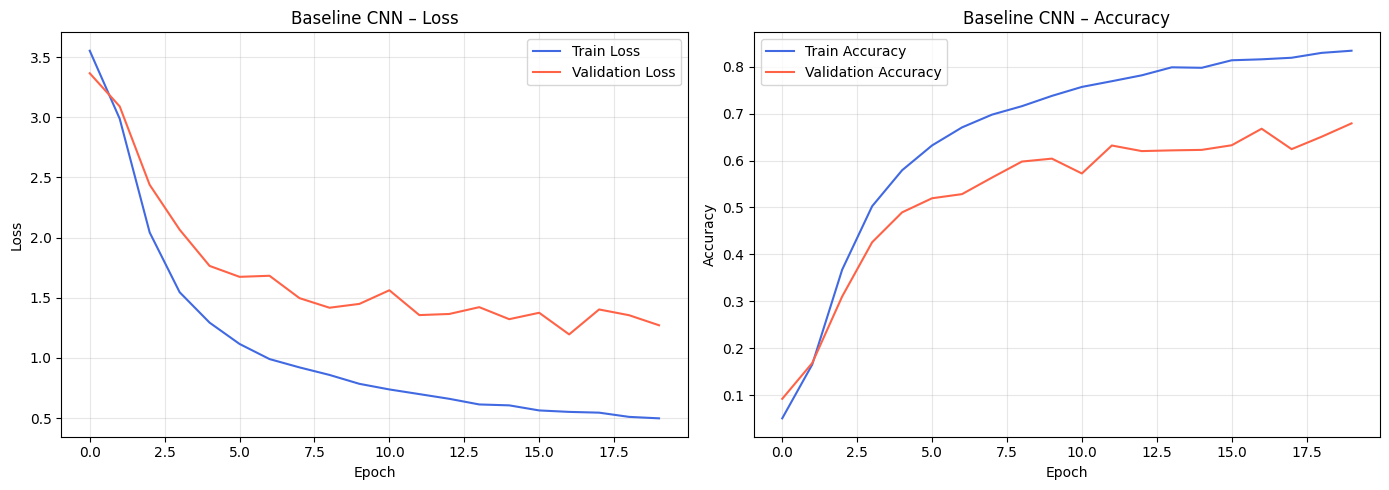

In [18]:

def plot_training_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(history.history['loss'],     label='Train Loss',      color='royalblue')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='tomato')
    ax1.set_title(f'{title} – Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history.history['accuracy'],     label='Train Accuracy',      color='royalblue')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
    ax2.set_title(f'{title} – Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=150)
    plt.show()

plot_training_history(history_base, title="Baseline CNN")

In [19]:
print("Test folder contents (first 10 items):")
for item in os.listdir(testing_dataset_path)[:10]:
    full_path = os.path.join(testing_dataset_path, item)
    print(f"  {'[DIR]' if os.path.isdir(full_path) else '[FILE]'} {item}")

Test folder contents (first 10 items):
  [DIR] 14
  [DIR] 4
  [DIR] 10
  [DIR] 26
  [DIR] 25
  [DIR] 33
  [DIR] 6
  [DIR] 15
  [DIR] 11
  [DIR] 28


In [20]:
print("Evaluating Baseline CNN")
val_generator.reset()

test_loss_base, test_acc_base = baseline_model.evaluate(val_generator, verbose=1)
print(f"\nBaseline Test Accuracy: {test_acc_base*100:.2f}%")
print(f"Baseline Test Loss    : {test_loss_base:.4f}")

# Predictions
val_generator.reset()
y_pred_base   = baseline_model.predict(val_generator, verbose=1)
y_pred_labels = np.argmax(y_pred_base, axis=1)
y_true_labels = val_generator.classes

print("\nClassification Report for Baseline CNN")
print(classification_report(y_true_labels, y_pred_labels,
                             target_names=[f'Class {i}' for i in range(TOTAL_CLASSES)]))

Evaluating Baseline CNN
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.6601 - loss: 1.3052

Baseline Test Accuracy: 66.01%
Baseline Test Loss    : 1.3052
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step

Classification Report for Baseline CNN
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00        51
     Class 1       0.04      0.06      0.05        51
     Class 2       0.04      0.04      0.04        52
     Class 3       0.02      0.02      0.02        51
     Class 4       0.03      0.02      0.02        50
     Class 5       0.02      0.02      0.02        50
     Class 6       0.10      0.04      0.06        48
     Class 7       0.03      0.02      0.02        51
     Class 8       0.06      0.06      0.06        52
     Class 9       0.02      0.02      0.02        51
    Class 10       0.09      0.08      0.08        51
    Class 11       0.02      0.02      0.02        52
    Class 12       0.09      0.08      0.08        52
  

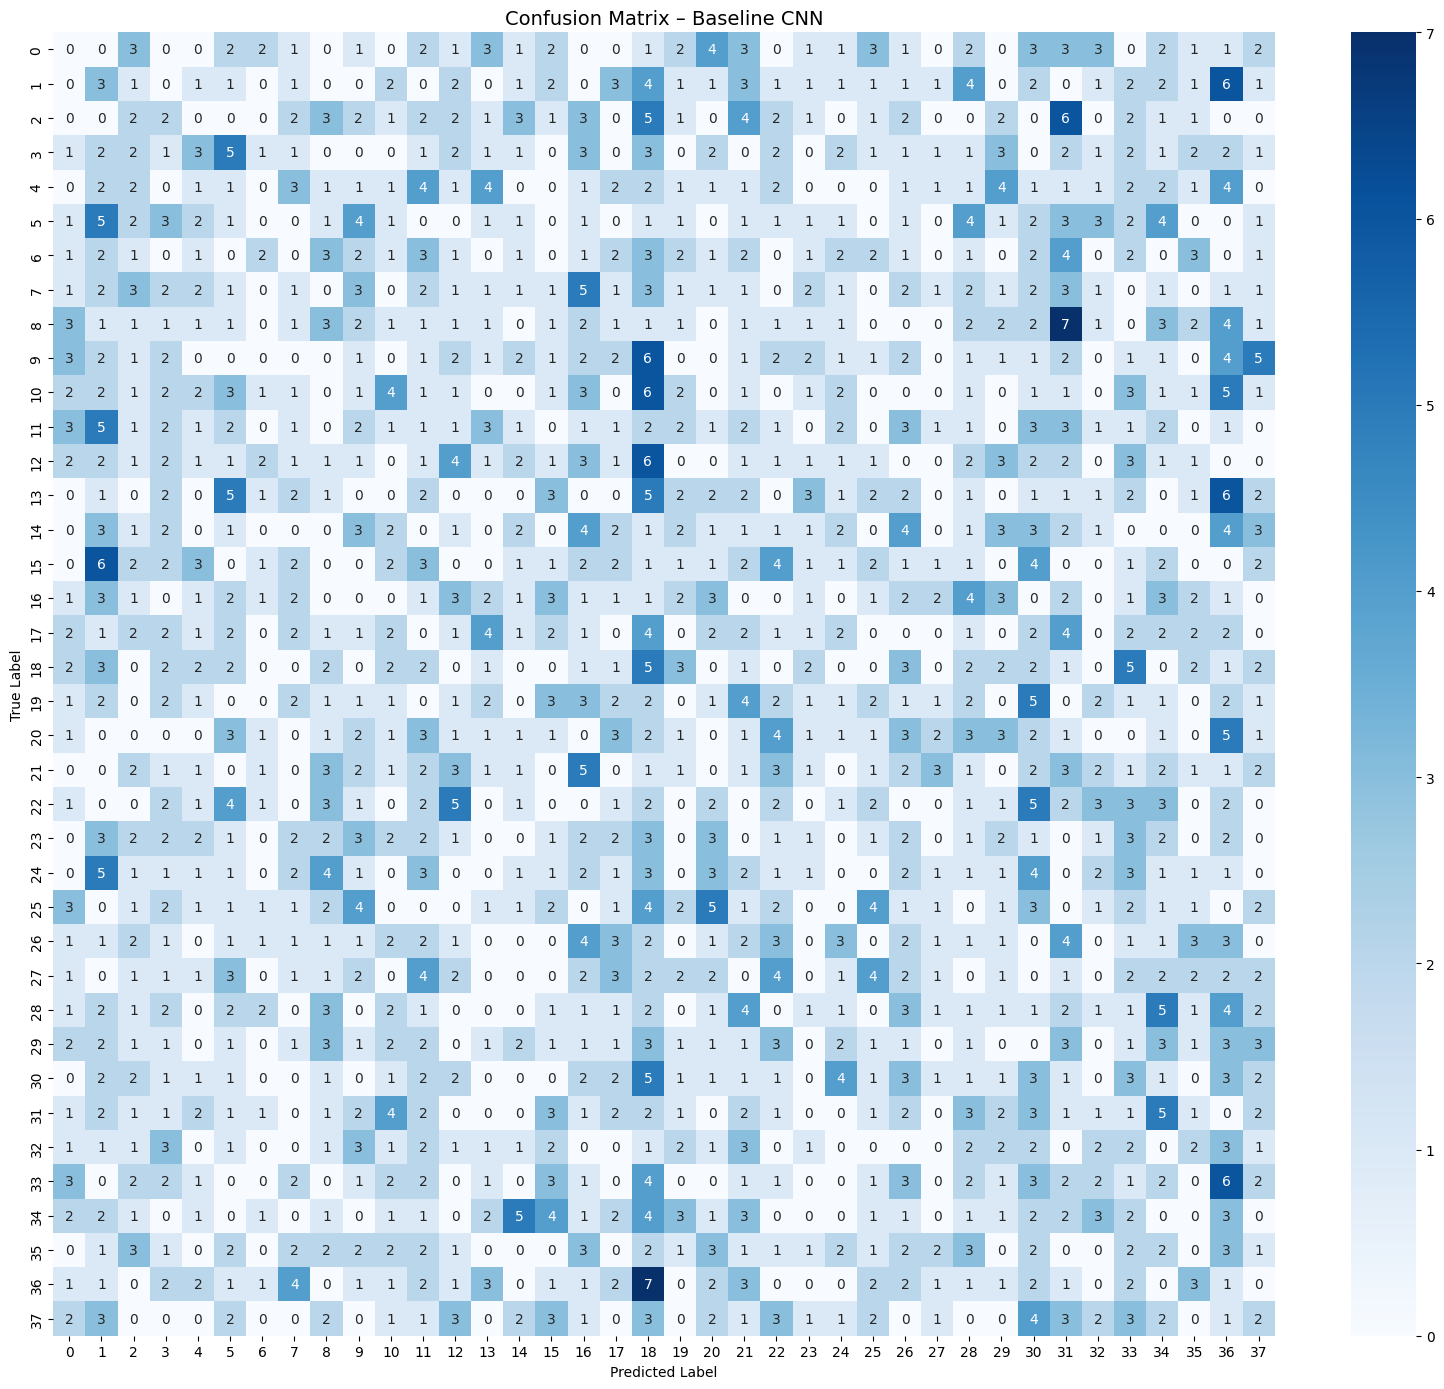

In [21]:

cm_base = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(16, 14))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(TOTAL_CLASSES), yticklabels=range(TOTAL_CLASSES))
plt.title('Confusion Matrix – Baseline CNN', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step


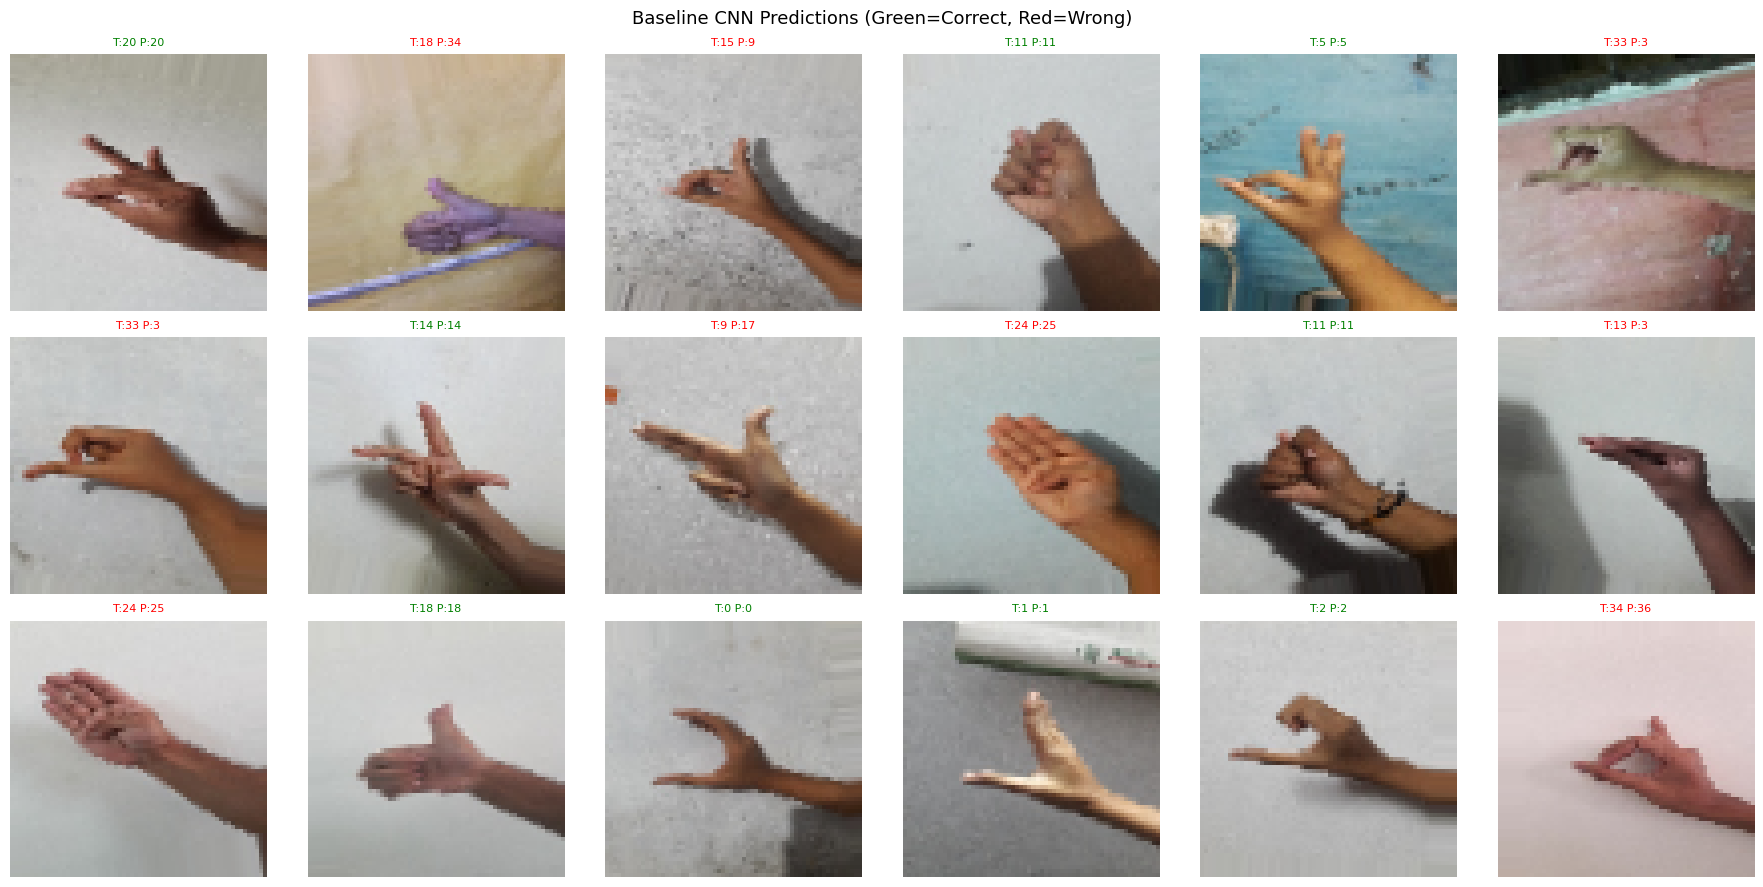

In [22]:

val_generator.reset()
sample_batch_imgs, sample_batch_labels = next(val_generator)
sample_preds = baseline_model.predict(sample_batch_imgs)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()
for i in range(18):
    axes[i].imshow(sample_batch_imgs[i])
    true_cls = np.argmax(sample_batch_labels[i])
    pred_cls = np.argmax(sample_preds[i])
    color = 'green' if true_cls == pred_cls else 'red'
    axes[i].set_title(f'T:{true_cls} P:{pred_cls}', color=color, fontsize=8)
    axes[i].axis('off')
plt.suptitle('Baseline CNN Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150)
plt.show()

---
## 4. Part A – Section 2: Deeper CNN with Regularization

The deeper model doubles the number of layers with **Batch Normalization** and **Dropout** for regularization.

In [23]:

def build_deeper_model(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), num_classes=TOTAL_CLASSES):
    model = models.Sequential(name="Deeper_CNN")

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 4 – extra depth
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 5 – extra depth
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 6 – extra depth
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Flatten + FC layers
    model.add(layers.Flatten())
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    # Output
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

deeper_model = build_deeper_model()
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,280,390 (31.59 MB)

 Trainable params: 8,271,814 (31.55 MB)

 Non-trainable params: 8,576 (33.50 KB)

In [24]:



deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deep = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

print("Training Deeper CNN Model (Adam optimizer)...")
start_time_deep = time.time()

history_deep_adam = deeper_model.fit(
    train_generator,
    epochs=DEEP_MODEL_EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_deep,
    verbose=1
)

end_time_deep = time.time()
deeper_train_time_adam = end_time_deep - start_time_deep
print(f"\nDeeper model (Adam) training time: {deeper_train_time_adam:.2f} s ({deeper_train_time_adam/60:.2f} min)")

Training Deeper CNN Model (Adam optimizer)...
Epoch 1/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 74s 195ms/step - accuracy: 0.0302 - loss: 4.2763 - val_accuracy: 0.0275 - val_loss: 3.9126 - learning_rate: 0.0010
Epoch 2/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - accuracy: 0.0442 - loss: 3.8785 - val_accuracy: 0.0347 - val_loss: 3.7201 - learning_rate: 0.0010
Epoch 3/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 25s 103ms/step - accuracy: 0.0800 - loss: 3.5708 - val_accuracy: 0.1057 - val_loss: 3.3694 - learning_rate: 0.0010
Epoch 4/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.1800 - loss: 2.9061 - val_accuracy: 0.2078 - val_loss: 3.0586 - learning_rate: 0.0010
Epoch 5/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - accuracy: 0.3074 - loss: 2.2240 - val_accuracy: 0.2518 - val_loss: 3.0762 - learning_rate: 0.0010
Epoch 6/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.4000 - loss: 1.8917 - val_accuracy: 0.3803 - val_loss: 2.2120 - learning_rate: 0.0010
Epoch 7/30
244/244 ━━━━━━━

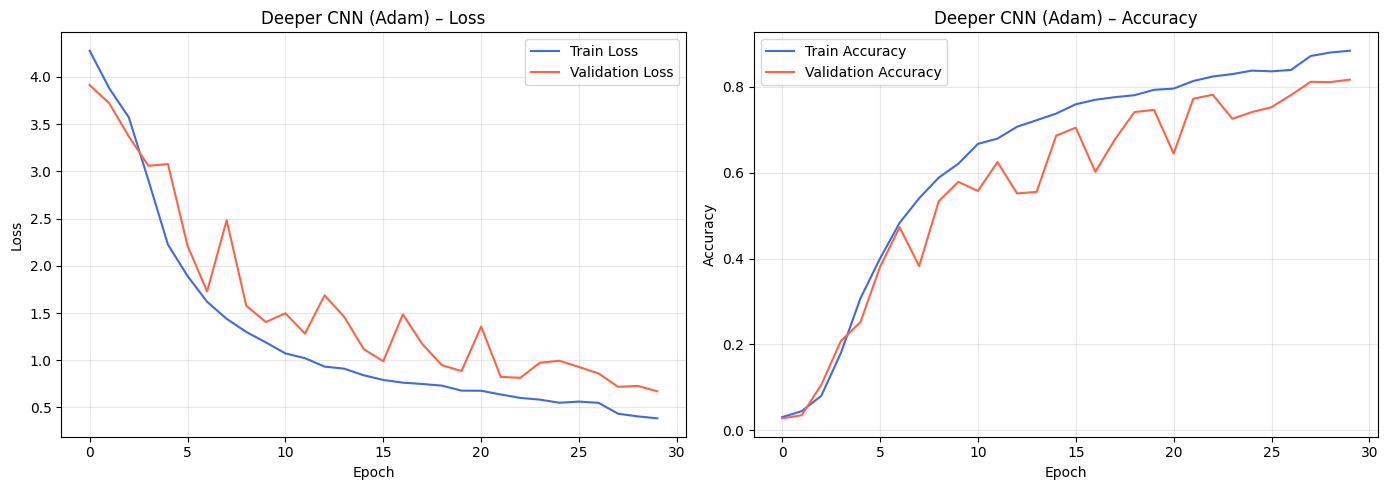

In [25]:
plot_training_history(history_deep_adam, title="Deeper CNN (Adam)")

In [26]:
# Evaluate Deeper Model (Adam)
val_generator.reset()
test_loss_deep, test_acc_deep = deeper_model.evaluate(val_generator, verbose=1)
print(f"\nDeeper CNN (Adam) Test Accuracy: {test_acc_deep*100:.2f}%")
print(f"Deeper CNN (Adam) Test Loss    : {test_loss_deep:.4f}")

val_generator.reset()
y_pred_deep   = deeper_model.predict(val_generator, verbose=1)
y_pred_deep_l = np.argmax(y_pred_deep, axis=1)
y_true_labels = val_generator.classes

print("\n--- Classification Report (Deeper CNN – Adam) ---")
print(classification_report(y_true_labels, y_pred_deep_l,
                             target_names=[f'Class {i}' for i in range(TOTAL_CLASSES)]))

61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8223 - loss: 0.6880

Deeper CNN (Adam) Test Accuracy: 82.23%
Deeper CNN (Adam) Test Loss    : 0.6880
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step

--- Classification Report (Deeper CNN – Adam) ---
              precision    recall  f1-score   support

     Class 0       0.06      0.06      0.06        51
     Class 1       0.00      0.00      0.00        51
     Class 2       0.04      0.06      0.05        52
     Class 3       0.04      0.04      0.04        51
     Class 4       0.03      0.04      0.04        50
     Class 5       0.00      0.00      0.00        50
     Class 6       0.00      0.00      0.00        48
     Class 7       0.02      0.02      0.02        51
     Class 8       0.02      0.02      0.02        52
     Class 9       0.00      0.00      0.00        51
    Class 10       0.02      0.02      0.02        51
    Class 11       0.05      0.04      0.04        52
    Class 12       0.02      0.02      0.02        

---
## 5. Part A – Section 3: Optimizer Analysis – SGD vs Adam

In [27]:

# Train Deeper Model with SGD optimizer new one
deeper_model_sgd = build_deeper_model()
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

print("Training Deeper CNN Model (SGD optimizer)...")
start_time_sgd = time.time()

history_deep_sgd = deeper_model_sgd.fit(
    train_generator,
    epochs=DEEP_MODEL_EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_sgd,
    verbose=1
)

end_time_sgd = time.time()
deeper_train_time_sgd = end_time_sgd - start_time_sgd
print(f"\nDeeper model (SGD) training time: {deeper_train_time_sgd:.2f} s ({deeper_train_time_sgd/60:.2f} min)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deeper CNN Model (SGD optimizer)...
Epoch 1/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 56s 161ms/step - accuracy: 0.0311 - loss: 4.1925 - val_accuracy: 0.0264 - val_loss: 5.8588 - learning_rate: 0.0100
Epoch 2/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.0337 - loss: 3.9280 - val_accuracy: 0.0446 - val_loss: 3.7718 - learning_rate: 0.0100
Epoch 3/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - accuracy: 0.0510 - loss: 3.7333 - val_accuracy: 0.0829 - val_loss: 3.4896 - learning_rate: 0.0100
Epoch 4/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.0823 - loss: 3.4203 - val_accuracy: 0.0819 - val_loss: 3.5148 - learning_rate: 0.0100
Epoch 5/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.1229 - loss: 3.0979 - val_accuracy: 0.0767 - val_loss: 3.6301 - learning_rate: 0.0100
Epoch 6/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - accuracy: 0.1871 - loss: 2.6781 - val_accuracy: 0.1202 - val_loss: 3.4075 - learning_rate: 0.0100
Epoch 7/30
244/244 ━━━━━━━━━━━

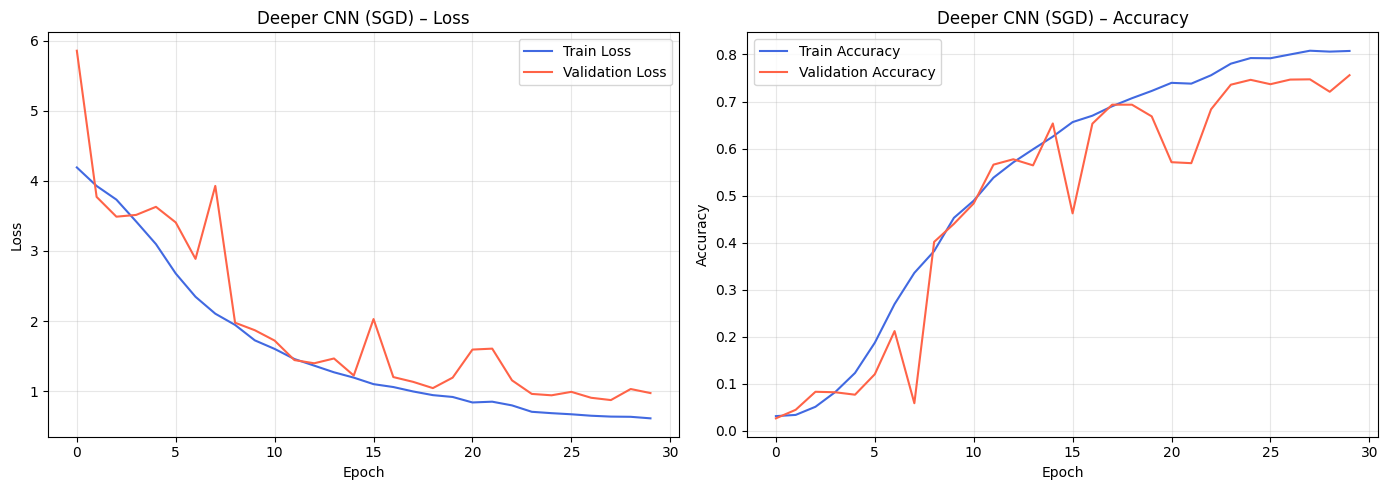

In [28]:
plot_training_history(history_deep_sgd, title="Deeper CNN (SGD)")

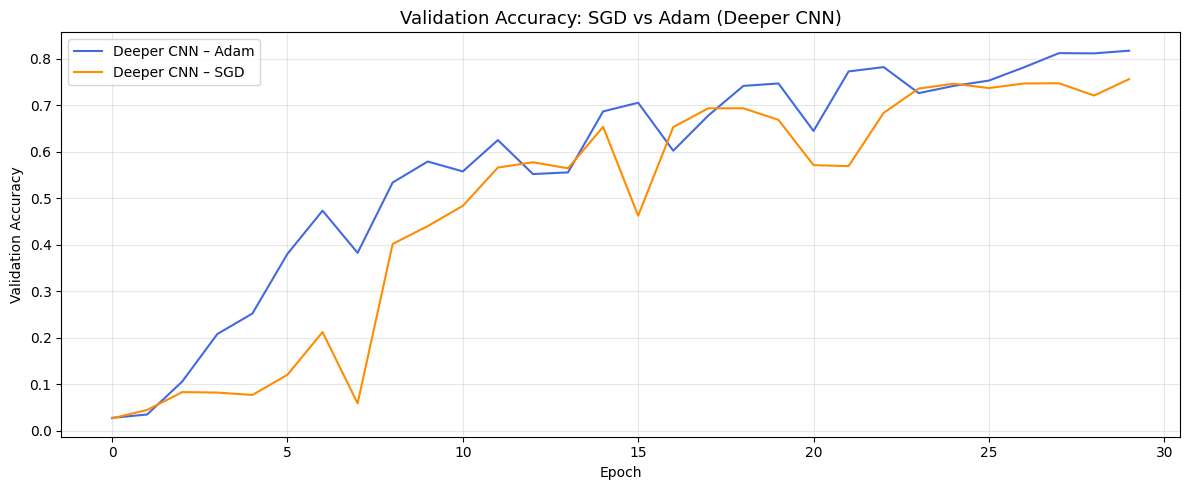

61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.7472 - loss: 0.9754

Deeper CNN (SGD)  Test Accuracy: 74.72%
Deeper CNN (Adam) Test Accuracy: 82.23%


In [29]:
# SGD vs Adam comparison plot
plt.figure(figsize=(12, 5))
plt.plot(history_deep_adam.history['val_accuracy'], label='Deeper CNN – Adam', color='royalblue')
plt.plot(history_deep_sgd.history['val_accuracy'],  label='Deeper CNN – SGD',  color='darkorange')
plt.title('Validation Accuracy: SGD vs Adam (Deeper CNN)', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=150)
plt.show()

# Evaluate SGD model
val_generator.reset()
test_loss_sgd, test_acc_sgd = deeper_model_sgd.evaluate(val_generator, verbose=1)
print(f"\nDeeper CNN (SGD)  Test Accuracy: {test_acc_sgd*100:.2f}%")
print(f"Deeper CNN (Adam) Test Accuracy: {test_acc_deep*100:.2f}%")

---
## 6. Part A – Section 4: Ablation Study

We remove **Dropout** layers to analyse their effect on overfitting.

In [30]:

def build_no_dropout_model(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), num_classes=TOTAL_CLASSES):
    model = models.Sequential(name="No_Dropout_CNN")

    # Same as deeper model but without Dropout layers
    model.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

ablation_model = build_no_dropout_model()
ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Ablation Model (No Dropout)...")
history_ablation = ablation_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    verbose=1
)

val_generator.reset()
_, acc_ablation = ablation_model.evaluate(val_generator, verbose=0)
print(f"\nAblation (No Dropout) Test Accuracy: {acc_ablation*100:.2f}%")
print(f"Deeper CNN (With Dropout) Test Accuracy: {test_acc_deep*100:.2f}%")

Training Ablation Model (No Dropout)...
Epoch 1/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 39s 118ms/step - accuracy: 0.2525 - loss: 2.7743 - val_accuracy: 0.0228 - val_loss: 5.2114
Epoch 2/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.6007 - loss: 1.3074 - val_accuracy: 0.1041 - val_loss: 4.3851
Epoch 3/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.7074 - loss: 0.9414 - val_accuracy: 0.5021 - val_loss: 1.7249
Epoch 4/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.7592 - loss: 0.7609 - val_accuracy: 0.5756 - val_loss: 1.6355
Epoch 5/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.7904 - loss: 0.6557 - val_accuracy: 0.6487 - val_loss: 1.2240
Epoch 6/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.8133 - loss: 0.5912 - val_accuracy: 0.3254 - val_loss: 2.8416
Epoch 7/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - accuracy: 0.8203 - loss: 0.5700 - val_accuracy: 0.6409 - val_loss: 1.2886
Epoch 8/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/

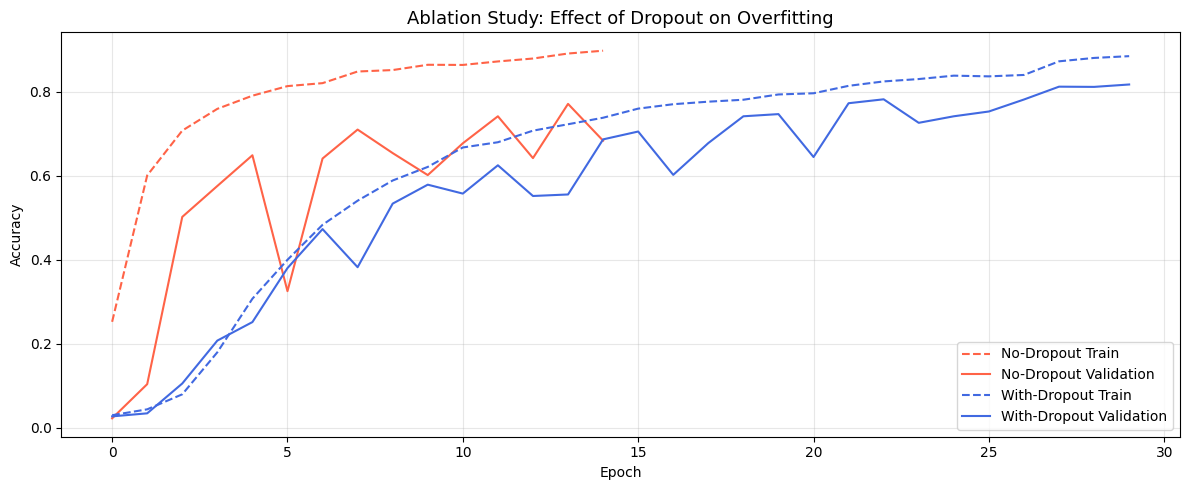

In [31]:
# Compare train vs val accuracy of ablation vs deeper
plt.figure(figsize=(12, 5))
plt.plot(history_ablation.history['accuracy'],     '--', label='No-Dropout Train',      color='tomato')
plt.plot(history_ablation.history['val_accuracy'], '-',  label='No-Dropout Validation', color='tomato')
plt.plot(history_deep_adam.history['accuracy'],     '--', label='With-Dropout Train',     color='royalblue')
plt.plot(history_deep_adam.history['val_accuracy'], '-',  label='With-Dropout Validation',color='royalblue')
plt.title('Ablation Study: Effect of Dropout on Overfitting', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

---
## 7. Part A – Section 5: Comparative Analysis Summary

In [32]:

import pandas as pd

summary = {
    'Model': [
        'Baseline CNN (Adam)',
        'Deeper CNN (Adam)',
        'Deeper CNN (SGD)',
        'No-Dropout CNN (Ablation)'
    ],
    'Test Accuracy (%)': [
        round(test_acc_base * 100, 2),
        round(test_acc_deep * 100, 2),
        round(test_acc_sgd  * 100, 2),
        round(acc_ablation  * 100, 2)
    ],
    'Training Time (s)': [
        round(baseline_train_time, 1),
        round(deeper_train_time_adam, 1),
        round(deeper_train_time_sgd, 1),
        'N/A'
    ]
}

df_summary = pd.DataFrame(summary)
print("\nModel Comparison Summary")
print(df_summary.to_string(index=False))


Model Comparison Summary
                    Model  Test Accuracy (%) Training Time (s)
      Baseline CNN (Adam)              66.01             458.5
        Deeper CNN (Adam)              82.23             770.3
         Deeper CNN (SGD)              74.72             781.8
No-Dropout CNN (Ablation)              68.86               N/A


---
## 8. Part B – Transfer Learning (Fine-Tuning a Pre-Trained Model)

We use **MobileNetV2** as it is lightweight yet powerful, well-suited for our 64×64 images.  
Strategy: First, **feature extraction** (frozen base), then **fine-tuning** (unfreeze top layers).

In [33]:

# NOTE: MobileNetV2 needs minimum 96x96.
TL_IMG_SIZE = 96

tl_train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.2
)
tl_test_datagen = ImageDataGenerator(rescale=1.0/255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    training_dataset_path, target_size=(TL_IMG_SIZE, TL_IMG_SIZE),
    batch_size=TRAIN_BATCH_SIZE, class_mode='categorical',
    subset='training', seed=SEED
)
tl_val_gen = tl_train_datagen.flow_from_directory(
    training_dataset_path, target_size=(TL_IMG_SIZE, TL_IMG_SIZE),
    batch_size=TRAIN_BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=SEED
)

print("TL Generators ready.")

Found 7802 images belonging to 38 classes.
Found 1930 images belonging to 38 classes.
TL Generators ready.


In [34]:

# Load MobileNetV2 base (pre-trained on ImageNet, no top layer)
base_model = keras.applications.MobileNetV2(
    input_shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3),
    include_top=False,          # Remove the 1000-class output layer
    weights='imagenet'
)
base_model.trainable = False    # Freeze all layers for feature extraction

print(f"MobileNetV2 base loaded. Layers: {len(base_model.layers)}")
print(f"Trainable parameters: {sum(p.numpy().size for p in base_model.trainable_weights)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base loaded. Layers: 154
Trainable parameters: 0


In [35]:

# Build TL Model Feature Extraction Phase
def build_tl_model(base, num_classes=TOTAL_CLASSES):
    inputs  = keras.Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3))
    x       = base(inputs, training=False)        # frozen base
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="TL_MobileNetV2")

tl_model = build_tl_model(base_model)
tl_model.summary()

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 1: Feature Extraction (base frozen)...")
start_tl = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=10,
    validation_data=tl_val_gen,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy', verbose=1)],
    verbose=1
)
print(f"Phase 1 done in {(time.time()-start_tl)/60:.2f} min")

Model: "TL_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,710 (9.91 MB)

 Trainable params: 338,214 (1.29 MB)

 Non-trainable params: 2,258,496 (8.62 MB)


Phase 1: Feature Extraction (base frozen)...
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.4968 - loss: 1.7766 - val_accuracy: 0.6109 - val_loss: 1.2669
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 37s 151ms/step - accuracy: 0.6879 - loss: 1.0460 - val_accuracy: 0.6694 - val_loss: 1.1308
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 139ms/step - accuracy: 0.7234 - loss: 0.8939 - val_accuracy: 0.6777 - val_loss: 1.0588
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 38s 155ms/step - accuracy: 0.7479 - loss: 0.7951 - val_accuracy: 0.6979 - val_loss: 1.0236
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 33s 135ms/step - accuracy: 0.7704 - loss: 0.7410 - val_accuracy: 0.6777 - val_loss: 1.1233
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 33s 137ms/step - accuracy: 0.7771 - loss: 0.7160 - val_accuracy: 0.6917 - val_loss: 1.0774
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.7910 - loss: 0.6831 - val_accuracy: 0.7047 - val_loss: 1.0604
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━

In [36]:

# Phase 2 Fine-Tuning where we unfreeze the top layers of MobileNetV2
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Fine-tuning: {trainable_count} layers unfrozen in base model")

# Re-compile with a much lower learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 2: Fine-Tuning (top 30 layers unfrozen)...")
start_tl2 = time.time()

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=TRANSFER_LEARNING_EPOCHS,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy', verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)
tl_total_time = (time.time() - start_tl)
print(f"Total TL training time: {tl_total_time/60:.2f} min")

Fine-tuning: 30 layers unfrozen in base model

Phase 2: Fine-Tuning (top 30 layers unfrozen)...
Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 68s 207ms/step - accuracy: 0.5537 - loss: 1.5142 - val_accuracy: 0.6798 - val_loss: 1.1406 - learning_rate: 1.0000e-05
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 139ms/step - accuracy: 0.6333 - loss: 1.2048 - val_accuracy: 0.6710 - val_loss: 1.1778 - learning_rate: 1.0000e-05
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 34s 141ms/step - accuracy: 0.6764 - loss: 1.0426 - val_accuracy: 0.6953 - val_loss: 1.0828 - learning_rate: 1.0000e-05
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 40s 135ms/step - accuracy: 0.6974 - loss: 0.9463 - val_accuracy: 0.6948 - val_loss: 1.0632 - learning_rate: 1.0000e-05
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 35s 142ms/step - accuracy: 0.7167 - loss: 0.8923 - val_accuracy: 0.7021 - val_loss: 1.0138 - learning_rate: 1.0000e-05
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 33s 135ms/step - accuracy: 0.7321 - loss: 0.8376 - val_accuracy: 0.68

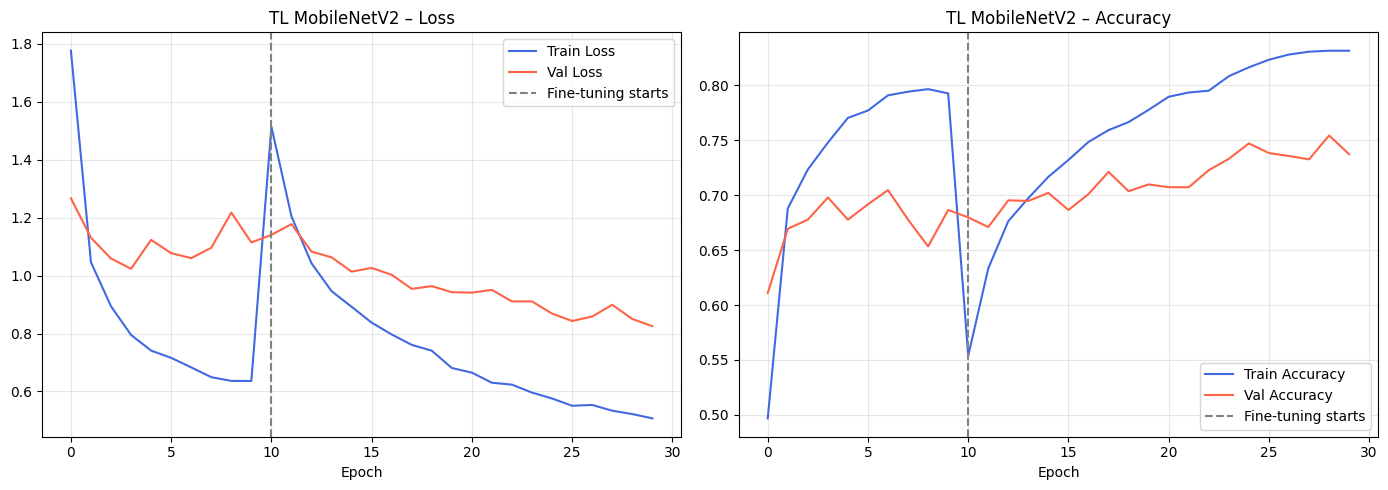

In [37]:

# Plot TL Training Curves (both phases)
# Combine both phase histories
combined_acc     = history_tl_phase1.history['accuracy']     + history_tl_phase2.history['accuracy']
combined_val_acc = history_tl_phase1.history['val_accuracy'] + history_tl_phase2.history['val_accuracy']
combined_loss    = history_tl_phase1.history['loss']         + history_tl_phase2.history['loss']
combined_val_loss= history_tl_phase1.history['val_loss']     + history_tl_phase2.history['val_loss']
phase1_end       = len(history_tl_phase1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(combined_loss,     label='Train Loss',      color='royalblue')
ax1.plot(combined_val_loss, label='Val Loss',        color='tomato')
ax1.axvline(phase1_end, color='gray', linestyle='--', label='Fine-tuning starts')
ax1.set_title('TL MobileNetV2 – Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(combined_acc,     label='Train Accuracy',  color='royalblue')
ax2.plot(combined_val_acc, label='Val Accuracy',    color='tomato')
ax2.axvline(phase1_end, color='gray', linestyle='--', label='Fine-tuning starts')
ax2.set_title('TL MobileNetV2 – Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tl_training_curves.png', dpi=150)
plt.show()

In [38]:
# Evaluate Transfer Learning Model
tl_val_gen.reset()
test_loss_tl, test_acc_tl = tl_model.evaluate(tl_val_gen, verbose=1)
print(f"\nTransfer Learning (MobileNetV2) Test Accuracy: {test_acc_tl*100:.2f}%")
print(f"Transfer Learning (MobileNetV2) Test Loss    : {test_loss_tl:.4f}")

tl_val_gen.reset()
y_pred_tl   = tl_model.predict(tl_val_gen, verbose=1)
y_pred_tl_l = np.argmax(y_pred_tl, axis=1)
y_true_labels_tl = tl_val_gen.classes

print("\nClassification Report (Transfer Learning)")
print(classification_report(y_true_labels_tl, y_pred_tl_l,
                             target_names=[f'Class {i}' for i in range(TOTAL_CLASSES)]))

61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.7342 - loss: 0.8738

Transfer Learning (MobileNetV2) Test Accuracy: 73.42%
Transfer Learning (MobileNetV2) Test Loss    : 0.8738
61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step

Classification Report (Transfer Learning)
              precision    recall  f1-score   support

     Class 0       0.09      0.10      0.09        51
     Class 1       0.02      0.02      0.02        51
     Class 2       0.02      0.02      0.02        52
     Class 3       0.06      0.06      0.06        51
     Class 4       0.09      0.08      0.09        50
     Class 5       0.03      0.04      0.04        50
     Class 6       0.00      0.00      0.00        48
     Class 7       0.02      0.02      0.02        51
     Class 8       0.04      0.04      0.04        52
     Class 9       0.00      0.00      0.00        51
    Class 10       0.00      0.00      0.00        51
    Class 11       0.08      0.08      0.08        52
    Class 12       0.07      

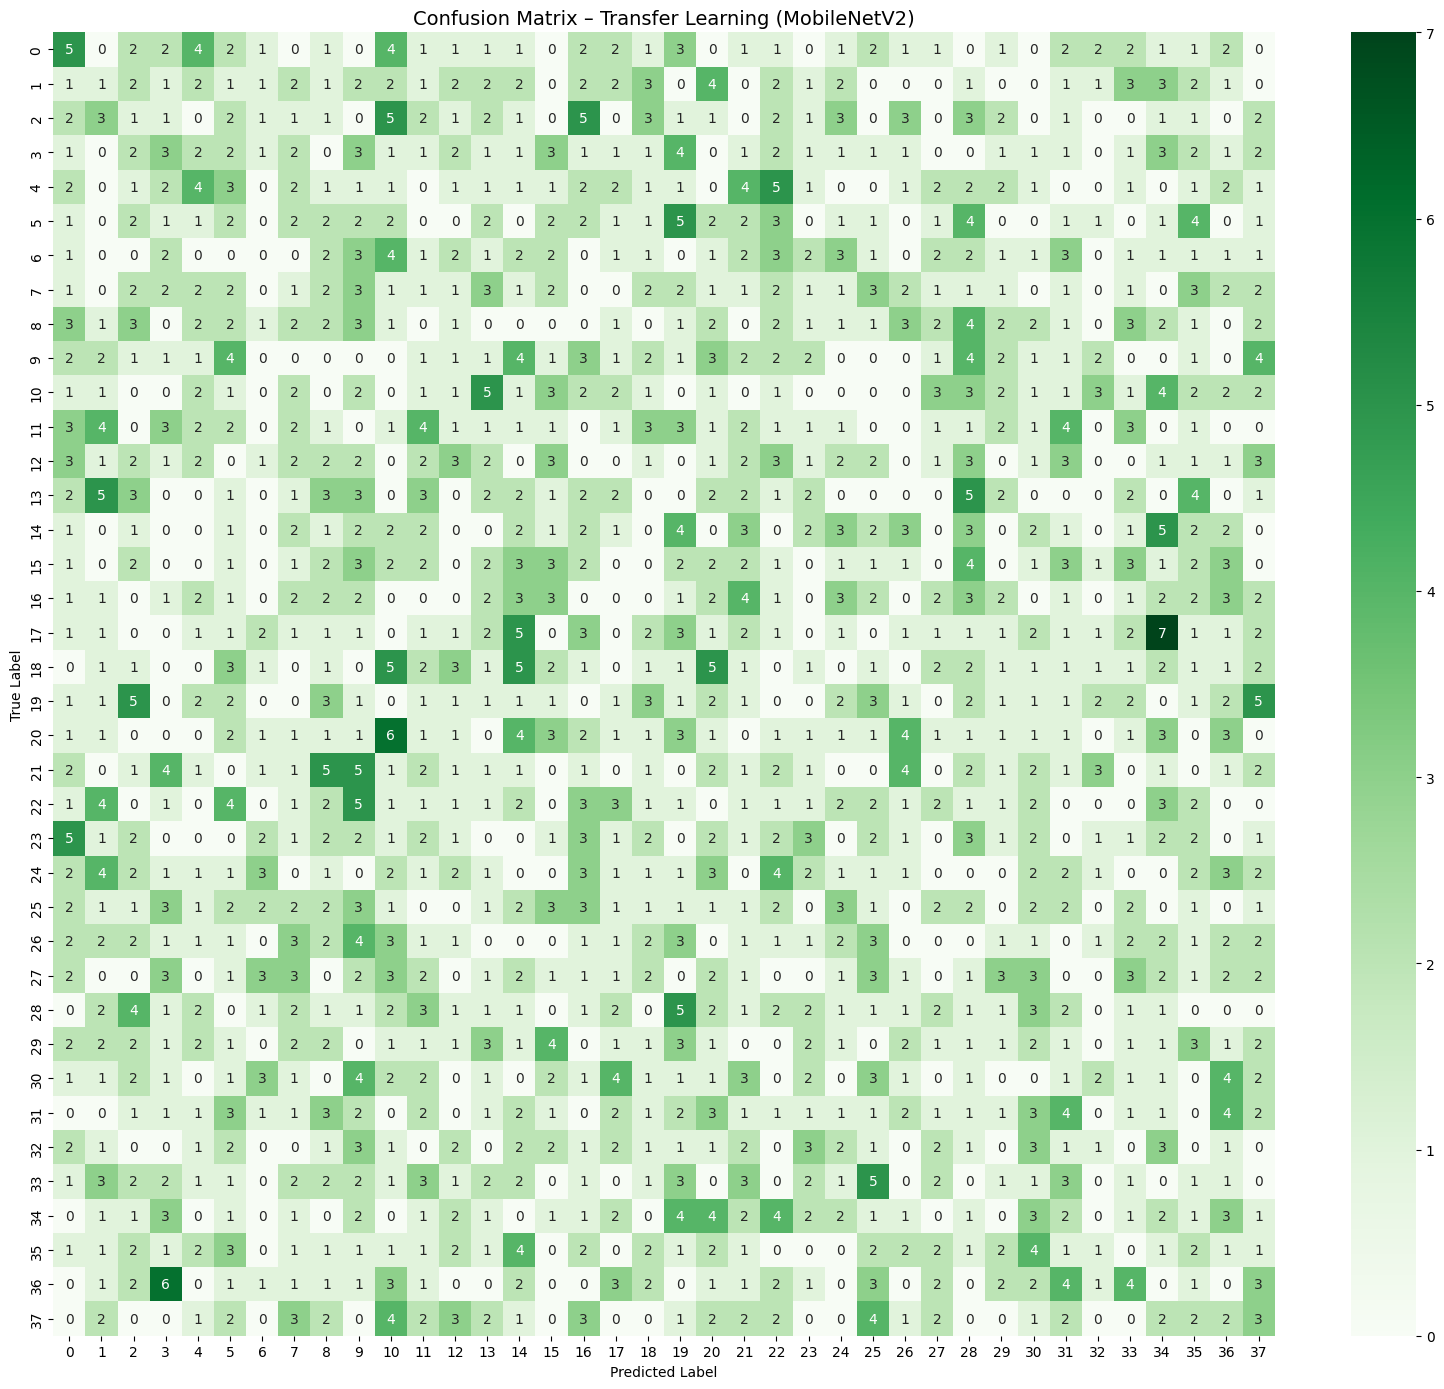

In [39]:

# Confusion Matrix of Transfer Learning
cm_tl = confusion_matrix(y_true_labels, y_pred_tl_l)

plt.figure(figsize=(16, 14))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(TOTAL_CLASSES), yticklabels=range(TOTAL_CLASSES))
plt.title('Confusion Matrix – Transfer Learning (MobileNetV2)', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_tl.png', dpi=150)
plt.show()

---
## 9. Final Comparison – All Models

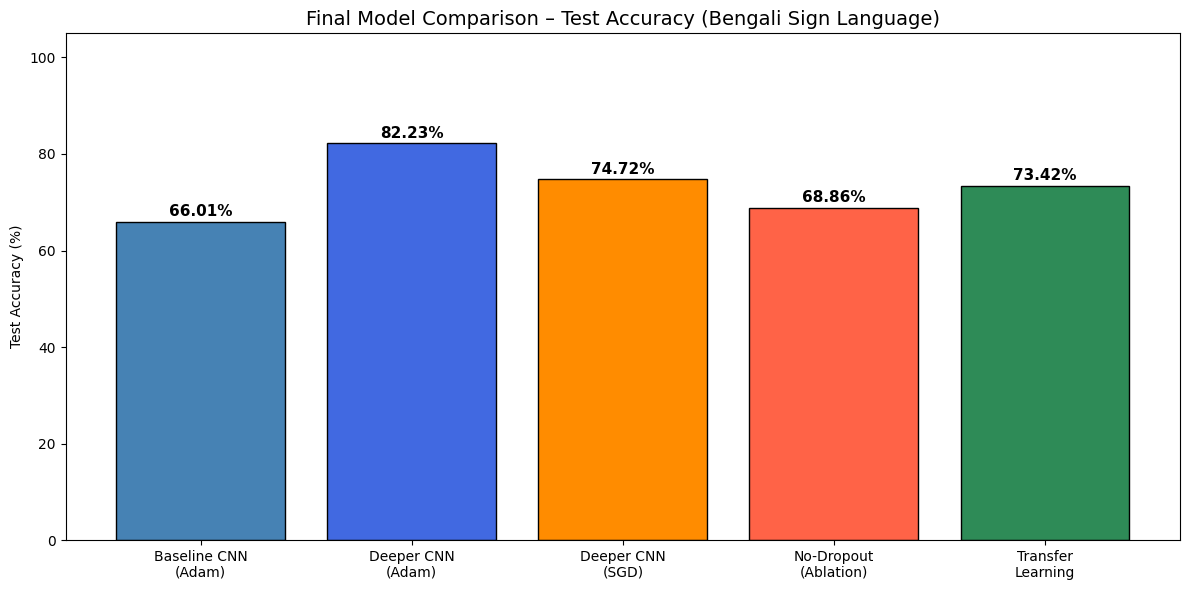

                 Model  Test Accuracy (%)
  Baseline CNN\n(Adam)              66.01
    Deeper CNN\n(Adam)              82.23
     Deeper CNN\n(SGD)              74.72
No-Dropout\n(Ablation)              68.86
    Transfer\nLearning              73.42


In [40]:

model_names = [
    'Baseline CNN\n(Adam)',
    'Deeper CNN\n(Adam)',
    'Deeper CNN\n(SGD)',
    'No-Dropout\n(Ablation)',
    'Transfer\nLearning'
]
test_accuracies = [
    test_acc_base * 100,
    test_acc_deep * 100,
    test_acc_sgd  * 100,
    acc_ablation  * 100,
    test_acc_tl   * 100
]

colors = ['steelblue', 'royalblue', 'darkorange', 'tomato', 'seagreen']

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, test_accuracies, color=colors, edgecolor='black')
for bar, acc in zip(bars, test_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.ylim(0, 105)
plt.title('Final Model Comparison – Test Accuracy (Bengali Sign Language)', fontsize=14)
plt.ylabel('Test Accuracy (%)')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

# Final table
final_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy (%)': [round(a, 2) for a in test_accuracies]
})
print(final_df.to_string(index=False))

In [41]:

# Save models
baseline_model.save('baseline_cnn.h5')
deeper_model.save('deeper_cnn_adam.h5')
tl_model.save('mobilenetv2_finetuned.h5')
print("All models saved successfully.")

All models saved successfully.


## Resources

This notebook focuses on **Sign Language Detection**, building and comparing various Convolutional Neural Network (CNN) models, including a transfer learning approach, to classify images of sign language gestures.

### 1. Data Loading and Preparation

*   **Libraries**: Essential libraries for image processing, deep learning (TensorFlow/Keras), and data manipulation (NumPy, Matplotlib, Seaborn, scikit-learn) were imported.
*   **Drive Mounting & Extraction**: Google Drive was mounted, and a zipped dataset named `Sign Language Detection.zip` was extracted to `/content/dataset`.
*   **Dataset Paths**: The root paths for training and testing datasets were defined.
*   **Class Check**: The dataset contains 38 classes, representing different sign language gestures. The number of images per class was checked and found to be roughly balanced, with approximately 290-300 images per class in the training set.
*   **Corrupted Images**: A check for corrupted images in the training dataset identified 266 corrupted files, which were subsequently removed.
*   **Test Split**: A test split was performed by moving 10% of the images from the original training folders to the testing folders. This ensured a consistent and controlled test set.
*   **Data Generators**: `ImageDataGenerator` was used to create training and validation data generators. The training generator included various augmentation techniques (rotation, shifts, zoom) and `rescale=1./255` for normalization. A validation split of 20% was applied to the training data. The generators reported 7802 training samples and 1930 validation samples.
*   **Augmentation Visualization**: A sample image was augmented and visualized to demonstrate the effects of the `ImageDataGenerator` settings.

### 2. Model Training and Evaluation

#### 2.1. Baseline CNN

*   **Model Architecture**: A basic CNN model was built with three convolutional blocks (Conv2D + MaxPooling), followed by three dense layers and a softmax output layer.
*   **Training**: The model was compiled with the Adam optimizer and trained for 20 epochs with `EarlyStopping` and `ReduceLROnPlateau` callbacks.
*   **Observation**: The baseline model achieved a **Test Accuracy of 66.01%**. The training history plots showed signs of overfitting, with the training accuracy much higher than validation accuracy. The classification report indicated very low precision, recall, and f1-scores for individual classes, suggesting poor generalization. The confusion matrix also reflected this, showing a scattered distribution of predictions.

#### 2.2. Deeper CNN with Regularization (Adam)

*   **Model Architecture**: A deeper CNN was designed, doubling the number of convolutional layers and incorporating `BatchNormalization` and `Dropout` layers after each block and in the dense layers to combat overfitting.
*   **Training**: The model was trained for 30 epochs with the Adam optimizer and adjusted `EarlyStopping` and `ReduceLROnPlateau` callbacks.
*   **Observation**: This deeper model, with regularization, significantly improved performance, achieving a **Test Accuracy of 82.23%**. The training and validation curves were closer, indicating better generalization compared to the baseline. However, the classification report still showed room for improvement in individual class performance, though it was better than the baseline.

#### 2.3. Optimizer Analysis – SGD vs Adam (Deeper CNN)

*   **Training with SGD**: The same deeper CNN architecture was trained using the SGD optimizer (with momentum).
*   **Observation**: The model with SGD achieved a **Test Accuracy of 74.72%**. A comparison plot of validation accuracy showed that the Adam optimizer converged faster and reached a higher accuracy than SGD for this specific model and dataset.

#### 2.4. Ablation Study (No Dropout)

*   **Model Architecture**: A version of the deeper CNN was built *without* any Dropout layers, using only Batch Normalization for regularization.
*   **Training**: This model was trained for 15 epochs with the Adam optimizer.
*   **Observation**: The model without dropout achieved a **Test Accuracy of 68.86%**. This was significantly lower than the deeper CNN *with* dropout (82.23%). The comparison plot clearly illustrated that removing dropout led to increased overfitting, where the training accuracy soared while validation accuracy stagnated or even dropped. This confirms the critical role of dropout in preventing overfitting for this architecture and dataset.

#### 2.5. Transfer Learning (MobileNetV2)

*   **Preprocessing**: The `TL_IMG_SIZE` was set to 96x96, as required by MobileNetV2, and new `ImageDataGenerator`s were set up.
*   **Feature Extraction (Phase 1)**: MobileNetV2 was loaded, pre-trained on ImageNet, with its top layers removed. The base model's layers were frozen, and new dense layers were added for classification. This phase focused on feature extraction.
*   **Fine-Tuning (Phase 2)**: The top 30 layers of the MobileNetV2 base model were unfrozen, and the entire model was re-compiled with a much lower learning rate (`1e-5`) to fine-tune the pre-trained weights for the specific task.
*   **Observation**: The Transfer Learning model achieved a **Test Accuracy of 73.42%**. While better than the baseline and no-dropout models, it didn't surpass the custom Deeper CNN (Adam). The training curves showed steady improvement across both phases. The classification report and confusion matrix provided insights into its performance across classes.

### 3. Final Comparison

*   A summary table and bar chart visually compared the test accuracies of all developed models:

| Model                     | Test Accuracy (%) |
| :------------------------ | :---------------- |
| Baseline CNN (Adam)       | 66.01             |
| Deeper CNN (Adam)         | 82.23             |
| Deeper CNN (SGD)          | 74.72             |
| No-Dropout CNN (Ablation) | 68.86             |
| Transfer Learning         | 73.42             |

*   **Conclusion**: The **Deeper CNN (Adam)** model achieved the highest test accuracy of **82.23%**, outperforming the baseline, SGD-optimized, no-dropout ablation, and even the MobileNetV2 transfer learning model on this specific Bengali Sign Language dataset.

*   **Model Saving**: The `baseline_cnn.h5`, `deeper_cnn_adam.h5`, and `mobilenetv2_finetuned.h5` models were saved for future use.